In [1]:
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from cdft.dft1d import dft_core

torch.set_default_dtype(torch.float64)
device = torch.device('cpu')

pi = np.pi
kB = 1.380649e-23
NA = 6.02214076e23

plt.rcParams.update({'text.usetex':True, 
'font.family':'sans-serif', 
'font.size':18, 
'axes.linewidth':1.1,
'text.latex.preamble': r'\usepackage{sfmath}'
})

colors = sns.color_palette("mako")

In [2]:
sigma_ff = 1.0
epsilon_ff = 1.0
parameters = {'sigma': sigma_ff, 'epsilon': epsilon_ff}

T = 1.2
bulk_density = torch.tensor([0.5925])

In [3]:
H = 7.5
pad = 4.0
dz = 0.02

system_size = H+2.0*pad
points = int(round(system_size/dz))
cell_size = system_size/points
kin = int(round(pad/cell_size))
kout = points-kin

In [4]:
epsilonw = 2*np.pi*epsilon_ff
Delta = sigma_ff/np.sqrt(2.0)
sigmaw = sigma_ff

def steele(z, sigma, epsilon):
    
    return epsilon*(0.4*(sigma/z)**10-(sigma/z)**4-sigma**4/(3*Delta*(z+0.61*Delta)**3))

dft = dft_core(parameters, T, system_size, points, device)

Vext = torch.zeros_like(dft.z)
Vext[0:kin] = np.inf
Vext[kout:] = np.inf
zp = dft.z[kin:kout]-pad
Vext[kin:kout] = steele(zp, sigmaw, epsilonw)+steele(H-zp, sigmaw, epsilonw)

dft.initial_condition(bulk_density, Vext, potential_cutoff=50.)

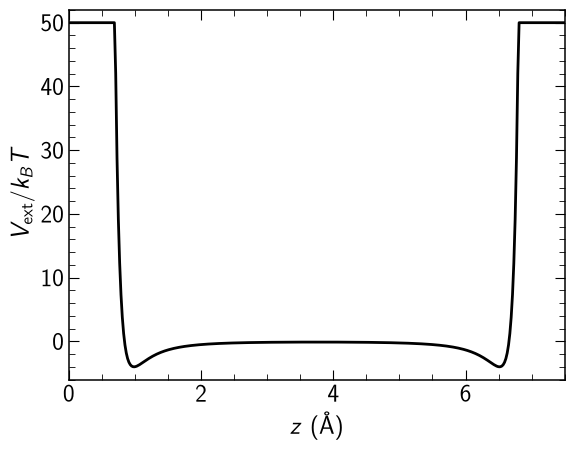

In [5]:
plt.plot(dft.z.cpu()-pad, dft.Vext.cpu(), color='k', lw=2.0)
plt.xlabel(r'$z$ (\AA{})', fontsize=18)
plt.ylabel(r'$V_{\mathsf{ext}}/k_BT$', fontsize=18)
plt.xlim(0.0, H)
plt.ylim(-6.0, 52.0)
plt.minorticks_on()
plt.tick_params(direction='in', right=True, top=True)
plt.tick_params(labelsize=18)
plt.tick_params(labelbottom=True, labeltop=False, labelright=False, labelleft=True)
plt.tick_params(direction='in', which='minor', length=4, bottom=True, top=True, left=True, right=True)
plt.tick_params(direction='in', which='major', length=7, bottom=True, top=True, left=True, right=True)

In [6]:
dft.equilibrium_density_profile(bulk_density, fmt='WB', solver='anderson',
                                anderson_damping=0.01, anderson_mmax=5, tol=1e-8)
print(dft.it, dft.error, dft.Omega)

722 tensor(9.9225e-09) tensor(-3.6759)


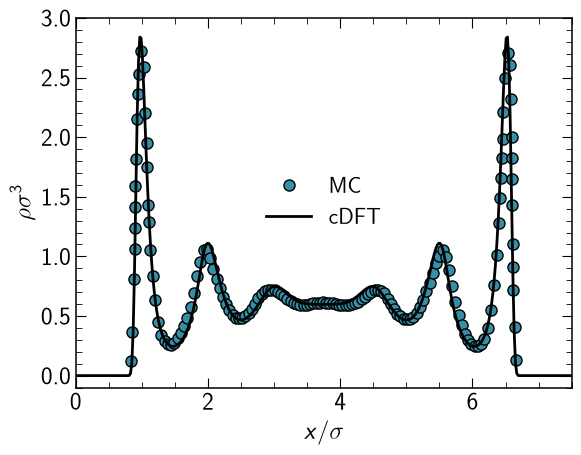

In [7]:
mc = np.loadtxt('data/lj-slitpore-steele-T1.2-rhob0.5925-H7.5-GEMC.dat')

plt.plot(mc[:,0], mc[:,1], 'o', color=colors[3], mew=1.0, ms=8, mec='k',label='MC')
plt.plot(dft.z-pad, dft.rho, color='k', lw=2.0, label='cDFT')
plt.xlabel(r'$x/ \sigma$', fontsize=18)
plt.ylabel(r'$\rho \sigma^3$', fontsize=18)
plt.xlim((0,H))
plt.ylim((-0.1,3.0))
plt.legend(fontsize=14)
plt.minorticks_on()
plt.tick_params(direction='in', right=True, top=True)
plt.tick_params(labelsize=18)
plt.tick_params(labelbottom=True, labeltop=False, labelright=False, labelleft=True)
plt.tick_params(direction='in', which='minor', length=4, bottom=True, top=True, left=True, right=True)
plt.tick_params(direction='in', which='major', length=7, bottom=True, top=True, left=True, right=True)
plt.legend(fontsize=16, frameon=False, edgecolor='k', loc='center')